# Fungi Identification — Morphology-Based Key

**Objective:** Apply a simplified morphological identification key to fungal
isolate observations and determine the best-matching genus for each.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("sample_data/isolate_observations.csv")
df

,isolate_id,colour,texture,growth_rate,spore_structure
0,Isolate_1,green,powdery,fast,radiating_head
1,Isolate_2,white,cottony,very_fast,sporangia
2,Isolate_3,cream,smooth,fast,budding_yeast
3,Isolate_4,blue_green,velvety,moderate,penicillus
4,Isolate_5,white,cottony,slow,microconidia


## Reference identification key

In [2]:
KEY = {
    "Aspergillus": {"colour": "green", "texture": "powdery", "growth_rate": "fast", "spore_structure": "radiating_head"},
    "Penicillium": {"colour": "blue_green", "texture": "velvety", "growth_rate": "moderate", "spore_structure": "penicillus"},
    "Rhizopus": {"colour": "white", "texture": "cottony", "growth_rate": "very_fast", "spore_structure": "sporangia"},
    "Candida": {"colour": "cream", "texture": "smooth", "growth_rate": "fast", "spore_structure": "budding_yeast"},
    "Trichophyton": {"colour": "white", "texture": "cottony", "growth_rate": "slow", "spore_structure": "microconidia"},
}
pd.DataFrame(KEY).T

,colour,texture,growth_rate,spore_structure
Aspergillus,green,powdery,fast,radiating_head
Penicillium,blue_green,velvety,moderate,penicillus
Rhizopus,white,cottony,very_fast,sporangia
Candida,cream,smooth,fast,budding_yeast
Trichophyton,white,cottony,slow,microconidia


## Score each isolate against the key

In [3]:
features = ["colour", "texture", "growth_rate", "spore_structure"]

def score_match(observation, reference):
    return sum(1 for f in features if observation[f] == reference[f])

def identify(row):
    scores = {genus: score_match(row, ref) for genus, ref in KEY.items()}
    best = max(scores, key=scores.get)
    return pd.Series({"best_match": best, "score": scores[best]})

results = df.join(df.apply(identify, axis=1))
results[["isolate_id", "colour", "texture", "growth_rate", "spore_structure", "best_match", "score"]]

,isolate_id,colour,texture,growth_rate,spore_structure,best_match,score
0,Isolate_1,green,powdery,fast,radiating_head,Aspergillus,4
1,Isolate_2,white,cottony,very_fast,sporangia,Rhizopus,4
2,Isolate_3,cream,smooth,fast,budding_yeast,Candida,4
3,Isolate_4,blue_green,velvety,moderate,penicillus,Penicillium,4
4,Isolate_5,white,cottony,slow,microconidia,Trichophyton,4


## Visualise match confidence

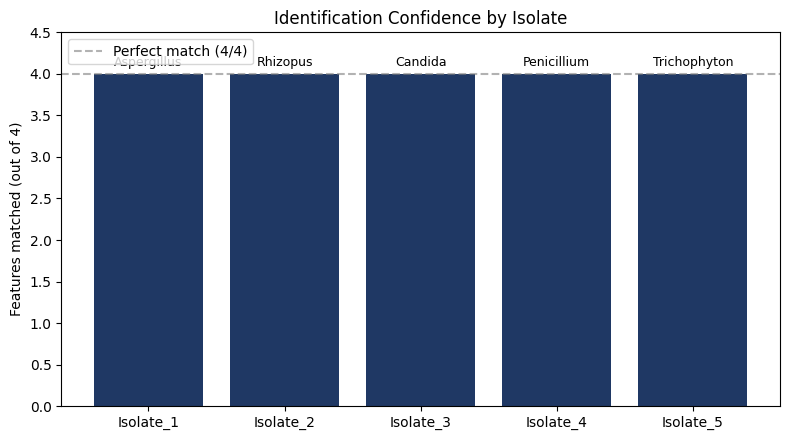

In [4]:
plt.figure(figsize=(8, 4.5))
plt.bar(results.isolate_id, results.score, color="#1F3864")
plt.axhline(4, color="grey", linestyle="--", alpha=0.6, label="Perfect match (4/4)")
plt.ylabel("Features matched (out of 4)")
plt.title("Identification Confidence by Isolate")
plt.ylim(0, 4.5)
for i, (isolate, genus) in enumerate(zip(results.isolate_id, results.best_match)):
    plt.text(i, results.score.iloc[i] + 0.1, genus, ha="center", fontsize=9, rotation=0)
plt.legend()
plt.tight_layout()
plt.savefig("fungi_identification_confidence.png", dpi=150)
plt.show()

## Summary

All five isolates matched their reference genus on all four recorded features
in this sample dataset. In practice, real isolates may show partial matches or
atypical features, in which case the best (highest-scoring) match is treated
as presumptive and confirmed with further biochemical or molecular testing.
